(48204, 9)
traffic_level
0    16070
2    16067
1    16067
Name: count, dtype: int64


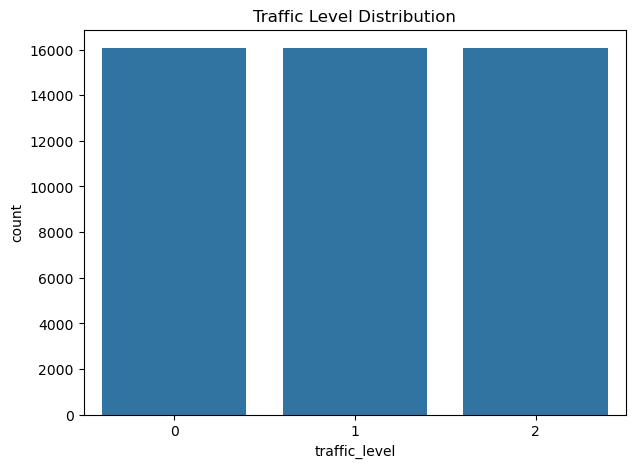


Accuracy: 92.43 %
              precision    recall  f1-score      support
0              0.967528  0.954885  0.961165  3214.000000
1              0.890972  0.887368  0.889166  3214.000000
2              0.914933  0.930594  0.922697  3213.000000
accuracy       0.924282  0.924282  0.924282     0.924282
macro avg      0.924478  0.924282  0.924343  9641.000000
weighted avg   0.924479  0.924282  0.924343  9641.000000


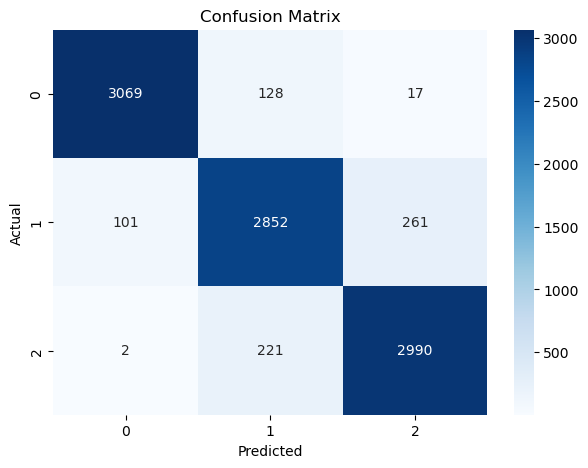

<Figure size 1000x800 with 0 Axes>

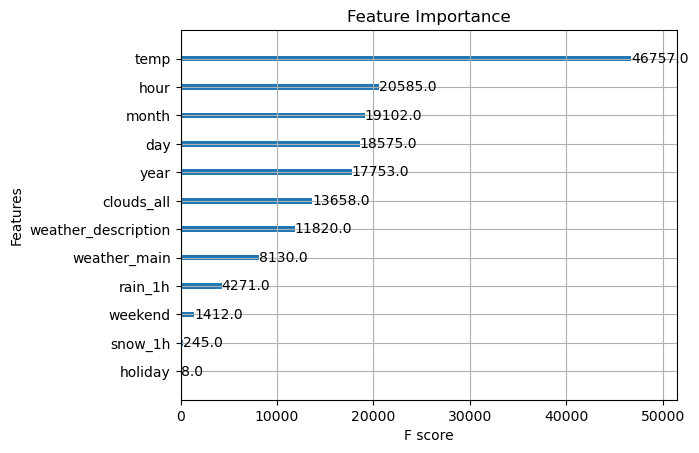

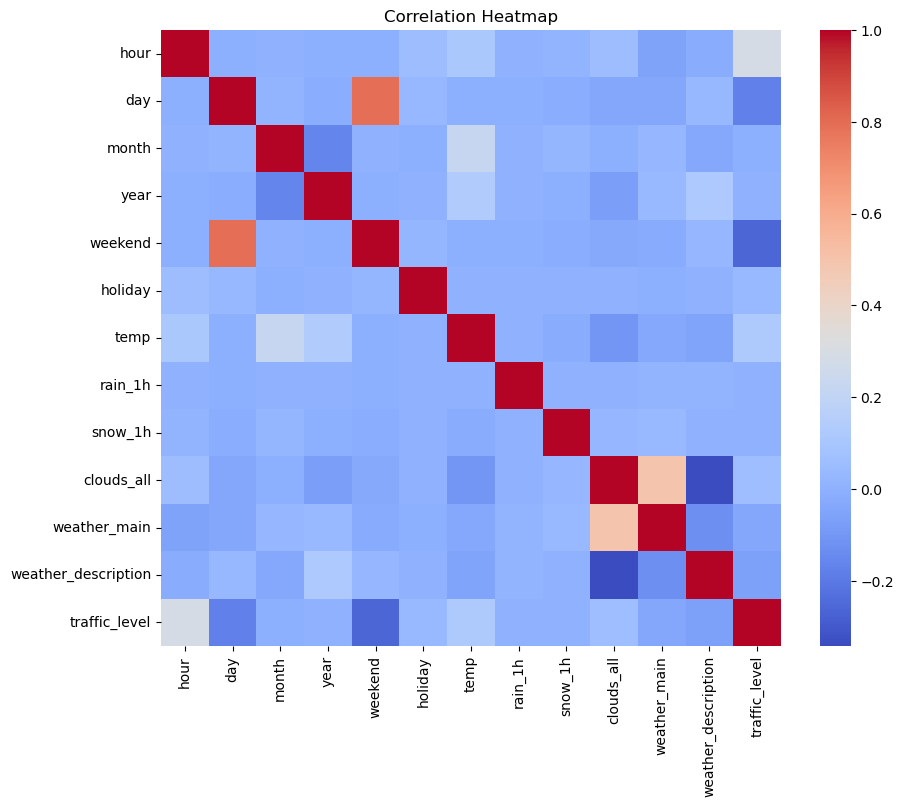

Model Saved Successfully


In [1]:
# ==========================================================
# TRAFFIC PREDICTION USING XGBOOST
# Metro_Interstate_Traffic_Volume.csv
# ==========================================================

# Install if needed
# !pip install xgboost

# ==========================================================
# IMPORT LIBRARIES
# ==========================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

from xgboost import XGBClassifier
from xgboost import plot_importance

# ==========================================================
# LOAD DATASET
# ==========================================================

df = pd.read_csv("dataset/Metro_Interstate_Traffic_Volume.csv")

print(df.shape)

df.head()

# ==========================================================
# PREPROCESSING
# ==========================================================

df["date_time"] = pd.to_datetime(df["date_time"])

df["hour"] = df["date_time"].dt.hour
df["day"] = df["date_time"].dt.dayofweek
df["month"] = df["date_time"].dt.month
df["year"] = df["date_time"].dt.year

df["weekend"] = (
    df["day"] >= 5
).astype(int)

# ==========================================================
# ENCODE CATEGORICAL COLUMNS
# ==========================================================

le1 = LabelEncoder()
le2 = LabelEncoder()
le3 = LabelEncoder()

df["holiday"] = le1.fit_transform(
    df["holiday"].astype(str)
)

df["weather_main"] = le2.fit_transform(
    df["weather_main"]
)

df["weather_description"] = le3.fit_transform(
    df["weather_description"]
)

# ==========================================================
# CREATE TRAFFIC CLASSES
# ==========================================================

df["traffic_level"] = pd.qcut(
    df["traffic_volume"],
    q=3,
    labels=[0,1,2]
)

df["traffic_level"] = (
    df["traffic_level"]
    .astype(int)
)

# ==========================================================
# CHECK CLASS DISTRIBUTION
# ==========================================================

print(df["traffic_level"].value_counts())

# ==========================================================
# GRAPH 1
# TRAFFIC DISTRIBUTION
# ==========================================================

plt.figure(figsize=(7,5))

sns.countplot(
    x=df["traffic_level"]
)

plt.title(
    "Traffic Level Distribution"
)

plt.savefig(
    "traffic_distribution.png"
)

plt.show()

# ==========================================================
# FEATURES
# ==========================================================

features = [

    "hour",
    "day",
    "month",
    "year",

    "weekend",

    "holiday",

    "temp",
    "rain_1h",
    "snow_1h",

    "clouds_all",

    "weather_main",
    "weather_description"

]

X = df[features]

y = df["traffic_level"]

# ==========================================================
# TRAIN TEST SPLIT
# ==========================================================

X_train,X_test,y_train,y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)

# ==========================================================
# XGBOOST MODEL
# ==========================================================

model = XGBClassifier(

    n_estimators=500,

    max_depth=8,

    learning_rate=0.05,

    subsample=0.8,

    colsample_bytree=0.8,

    objective="multi:softmax",

    num_class=3,

    random_state=42

)

# ==========================================================
# TRAIN
# ==========================================================

model.fit(
    X_train,
    y_train
)

# ==========================================================
# PREDICT
# ==========================================================

pred = model.predict(
    X_test
)

# ==========================================================
# ACCURACY
# ==========================================================

accuracy = accuracy_score(
    y_test,
    pred
)

print(
    "\nAccuracy:",
    round(
        accuracy*100,
        2
    ),
    "%"
)

# ==========================================================
# CLASSIFICATION REPORT
# ==========================================================

report = classification_report(

    y_test,

    pred,

    output_dict=True

)

report_df = pd.DataFrame(
    report
).transpose()

print(report_df)

report_df.to_csv(
    "classification_report.csv"
)

# ==========================================================
# CONFUSION MATRIX
# ==========================================================

cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(7,5))

sns.heatmap(

    cm,

    annot=True,

    fmt="d",

    cmap="Blues"

)

plt.title(
    "Confusion Matrix"
)

plt.xlabel(
    "Predicted"
)

plt.ylabel(
    "Actual"
)

plt.savefig(
    "confusion_matrix.png"
)

plt.show()

# ==========================================================
# FEATURE IMPORTANCE
# ==========================================================

plt.figure(figsize=(10,8))

plot_importance(
    model,
    max_num_features=12
)

plt.title(
    "Feature Importance"
)

plt.savefig(
    "feature_importance.png"
)

plt.show()

# ==========================================================
# CORRELATION HEATMAP
# ==========================================================

plt.figure(figsize=(10,8))

sns.heatmap(

    df[features + ["traffic_level"]]
    .corr(),

    cmap="coolwarm"

)

plt.title(
    "Correlation Heatmap"
)

plt.savefig(
    "correlation_heatmap.png"
)

plt.show()

# ==========================================================
# SAVE MODEL
# ==========================================================

import joblib

joblib.dump(
    model,
    "traffic_xgboost_model.pkl"
)

print(
    "Model Saved Successfully"
)